# Task 3: Prediction of perturbation effect

In [1]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pathlib import Path
import numpy as np
import pandas as pd

import scanpy as sc
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from scmlcourse.perturbation import *

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
data_dir = Path("../../data")
pl.seed_everything(0)

Seed set to 0


0

### Data Loading


In [3]:
data_module = DataModule(data_dir/"qced_data.h5ad", n_workers=8, n_top_genes=2000, retain_adata = True)

/omics/groups/OE0436/data/ntoulouse/scMLCourse/src/scmlcourse/perturbation.py:82: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  self.adata.layers["raw"] = self.adata.X.copy()


Co-culture cell_name
CELL_145219      CCND2_Co-culture
CELL_145220       CD44_Co-culture
CELL_145221    control_Co-culture
CELL_145223    control_Co-culture
CELL_145226      JMJD7_Co-culture
                      ...        
CELL_218327       CTSO_Co-culture
CELL_218328       JAK2_Co-culture
CELL_218329    control_Co-culture
CELL_218330     CDKN2B_Co-culture
CELL_218331    control_Co-culture
Name: perturbed_condition, Length: 35063, dtype: str


/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:434: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "pvals"] = pvals[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.

            group  names    scores  logfoldchanges     pvals  pvals_adj
0  A2M_Co-culture  CCNL1  3.534528        0.807921  0.000409   0.618589
1  A2M_Co-culture  GINS2  3.428176        0.684672  0.000608   0.618589
2  A2M_Co-culture  KIF2C  2.964464        0.716698  0.003032   1.000000
3  A2M_Co-culture   TYMS  2.883070        0.646276  0.003938   1.000000
4  A2M_Co-culture  HSPA8  2.786822        0.273587  0.005323   1.000000
Control cell_name
CELL_5         control_Control
CELL_6          IFNGR1_Control
CELL_7        C6orf226_Control
CELL_8          CDKN1A_Control
CELL_9            EMP1_Control
                    ...       
CELL_57618     control_Control
CELL_57620     control_Control
CELL_57623     control_Control
CELL_57625     control_Control
CELL_57627     control_Control
Name: perturbed_condition, Length: 28091, dtype: str


/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:434: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "pvals"] = pvals[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.

         group   names    scores  logfoldchanges     pvals  pvals_adj
0  A2M_Control    UPP1  4.303002        0.466861  0.000017   0.034306
1  A2M_Control   LIMA1  3.614829        0.443484  0.000301   0.305956
2  A2M_Control   MKNK2  3.038503        0.662412  0.002378   1.000000
3  A2M_Control  PARP14  2.753513        0.701850  0.005896   1.000000
4  A2M_Control   VAMP5  2.687629        0.493512  0.007196   1.000000
IFNγ cell_name
CELL_57628      control_IFNγ
CELL_57629        CSPG4_IFNγ
CELL_57630      control_IFNγ
CELL_57631      control_IFNγ
CELL_57632      control_IFNγ
                   ...      
CELL_145210    C19orf48_IFNγ
CELL_145211     control_IFNγ
CELL_145212     control_IFNγ
CELL_145213       AEBP1_IFNγ
CELL_145214     control_IFNγ
Name: perturbed_condition, Length: 43797, dtype: str


/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:434: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "pvals"] = pvals[global_indices]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.

      group  names    scores  logfoldchanges     pvals  pvals_adj
0  A2M_IFNγ  CLSPN  3.996953        0.809364  0.000064   0.076615
1  A2M_IFNγ  H2AFZ  3.959012        0.333241  0.000075   0.076615
2  A2M_IFNγ  HMGB2  3.507424        0.779745  0.000452   0.231565
3  A2M_IFNγ  HMGB3  3.462938        0.736104  0.000534   0.231565
4  A2M_IFNγ  SYNE2  3.399292        0.755544  0.000676   0.231565
logfoldchanges has shape (2036, 150)
['CD47_Co-culture', 'CD47_Control', 'CD47_IFNγ', 'CDH19_Co-culture', 'CDH19_Control', 'CDH19_IFNγ', 'CSPG4_Co-culture', 'CSPG4_Control', 'CSPG4_IFNγ', 'CKS1B_Co-culture', 'CKS1B_Control', 'CKS1B_IFNγ', 'A2M_Co-culture', 'A2M_Control', 'A2M_IFNγ', 'JAK1_Co-culture', 'JAK1_Control', 'JAK1_IFNγ', 'CCR10_Co-culture', 'CCR10_Control', 'CCR10_IFNγ', 'CHCHD2_Co-culture', 'CHCHD2_Control', 'CHCHD2_IFNγ', 'CDKN1A_Co-culture', 'CDKN1A_Control', 'CDKN1A_IFNγ', 'CD59_Co-culture', 'CD59_Control', 'CD59_IFNγ'] ['control_Co-culture', 'control_Control', 'control_IFNγ', 'ACTA2_

In [4]:
print(
    data_module.adata,
    data_module.n_vars,
    data_module.batch_size,
    sep="\n------\n")

View of AnnData object with n_obs × n_vars = 106951 × 2036
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier', 'perturbed_gene', 'perturbed_condition'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'hi

## Simplistic Baseline: Small MLP

In [5]:
data_module.adata.obs["train_set"] = data_module.adata.obs["perturbed_condition"].map(lambda x: x in data_module.train_genes)
data_module.adata.obs[["perturbed_gene", "perturbation_2", "train_set"]].value_counts().reset_index().pivot(index="perturbed_gene", columns=["perturbation_2", "train_set"])

/tmp/ipykernel_1828717/1034738237.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  data_module.adata.obs["train_set"] = data_module.adata.obs["perturbed_condition"].map(lambda x: x in data_module.train_genes)


count                                            
perturbation_2   IFNγ Co-culture Control  IFNγ Co-culture Control
train_set       True       True    True  False      False   False
perturbed_gene                                                   
A2M                 0          0       0   514        412     351
ACTA2             590        428     384     0          0       0
AEBP1             518        376     371     0          0       0
AGA               411        369     305     0          0       0
AHNAK             424        294     309     0          0       0
APOD              453        341     287     0          0       0
APOE              447        343     305     0          0       0
ATP1B1            443        317     331     0          0       0
B2M               524        456     344     0          0       0
BZW2              364        308     269     0          0       0
C6orf226          405        318     258     0          0       0
C19orf48          442        358     288     0          0       0
CCND2             397        322     266     0          0       0
CCR10               0          0       0   391        309     250
CD44              432        406     329     0          0       0
CD47                0          0       0   418        292     284
CD58              406        446     280     0          0       0
CD59                0          0       0   510        393     302
CD151             362        335     267     0          0       0
CD274             507        358     323     0          0       0
CDH19               0          0       0   454        367     321
CDKN1A              0          0       0   389        342     286
CDKN2B            409        303     247     0          0       0
CHCHD2              0          0       0   418        321     244
CITED1            413        340     330     0          0       0
CKS1B               0          0       0   402        281     253
CMSS1             395        328     253     0          0       0
CSPG4               0          0       0   456        382     315
CTSA              362        282     274     0          0       0
CTSB              424        360     273     0          0       0
CTSD              472        390     318     0          0       0
CTSL              352        284     262     0          0       0
CTSO              416        308     283     0          0       0
CYP27A1           352        303     268     0          0       0
DLL3              366        278     244     0          0       0
EMP1              375        288     260     0          0       0
FBXO32            391        374     244     0          0       0
FGFR1             464        383     309     0          0       0
FMN1              419        307     258     0          0       0
FSTL3             407        333     269     0          0       0
GSN               354        305     271     0          0       0
HLA-A             381        321     251     0          0       0
HLA-DRB5          406        345     258     0          0       0
IDH2              350        343     248     0          0       0
IFNGR1            287        406     196     0          0       0
IFNGR2            380        579     212     0          0       0
JAK1                0          0       0   334        458     208
JAK2              336        515     238     0          0       0
JMJD7             360        342     199     0          0       0
MFGE8             422        318     230     0          0       0
control         23093      17396   14166     0          0       0

In [6]:
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint
log_dir = Path("../logs")
log_dir.mkdir(exist_ok=True)
checkpointer = ModelCheckpoint(
    dirpath=log_dir,
    filename="epoch:{epoch}-val_loss:{val_loss:.2f}",
    monitor=None,
    verbose=False
)

In [7]:
mlp_config = dict(
    in_dim=data_module.n_vars,
    out_dim=data_module.n_vars,
    hidden_dims=(data_module.n_vars,)*3,
)
baseline_model = Baseline(mlp_config)
cond_model = condMLP(mlp_config)
pert_config = mlp_config.copy()
pert_config.update(in_dim=data_module.n_vars*2)
pert_model = pertMLP(pert_config)

In [11]:
def get_last_version(dir:Path):
    dirs = [d for d in dir.glob("version_*")]
    v = [d.stem[-1]]
    return dirs[np.argmax(v)]
def get_ckpt(dir:Path, last = False):
    if last and (dir/"last.ckpt").exists():
        return dir/"last.ckpt"
    ckpts = [c for c in dir.glob("*.ckpt") if not "last" in c.name]
    vloss = [c.stem.split("=")[-1] for c in ckpts]
    return ckpts[np.argmin(vloss)]


baseline_model, baseline_test_scores, baseline_logged_dir = train(
    baseline_model,
    data_module,
    max_epochs = 1000,
    patience = 15,
    log_dir = "logs",
    run_name = "baseline",
    test_on="best",
    seed = 0,)
cond_model, cond_test_scores, cond_logged_dir = train(
    cond_model,
    data_module,
    max_epochs = 1000,
    patience = 3,
    log_dir = "logs",
    run_name = "cond_baseline",
    test_on="best",
    seed = 0,)
pert_model, pert_test_scores, pert_logged_dir = train(
    pert_model,
    data_module,
    max_epochs = 1000,
    patience = 3,
    log_dir = "logs",
    run_name = "pert_baseline",
    test_on="best",
    seed = 0,)

import gc
gc.collect()

Seed set to 0
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name   | Type    | Params | Mode  | FLOPs
---------------------------------------------------
0 | module | MLP     | 16.6 M | train | 0    
1 | loss   | MSELoss | 0      | train | 0    
---------------------------------------------------
16.6 M    Trainable params
0         Non-trainable params
16.6 M    Total params

Training for max 1000 epochs...
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/n

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0r

Epoch 0: 100%|██████████| 867/867 [00:04<00:00, 194.55it/s, v_num=19, train_loss_step=36.00, val_loss=35.20, val_pearson=0.259, train_loss_epoch=34.90]

...

Monitored metric val_loss did not improve in the last 3 records. Best score: 12.259. Signaling Trainer to stop.


Epoch 16: 100%|██████████| 867/867 [00:05<00:00, 164.54it/s, v_num=8, train_loss_step=12.70, val_loss=13.10, val_pearson=0.259, train_loss_epoch=13.50]


Restoring states from the checkpoint path at /omics/groups/OE0436/data/ntoulouse/scMLCourse/notebooks/logs/pert_baseline/version_8/epoch=13-val_loss=12.2589.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /omics/groups/OE0436/data/ntoulouse/scMLCourse/notebooks/logs/pert_baseline/version_8/epoch=13-val_loss=12.2589.ckpt
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is depr

Testing DataLoader 0: 100%|██████████| 107/107 [00:00<00:00, 406.33it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           122.26859283447266
      test_pearson          0.17296521365642548
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


3343

In [12]:
plot_cols = ["train_loss_epoch", "val_loss", ]

array([[<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>]], dtype=object)

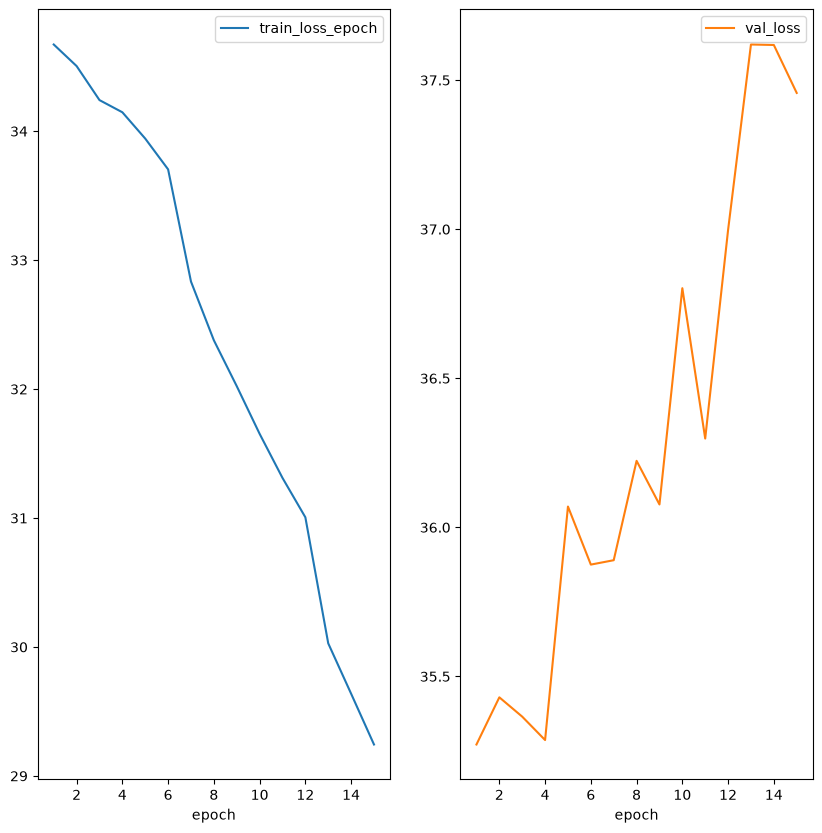

In [13]:
logs = pd.read_csv(baseline_logged_dir+"/metrics.csv")
logs.groupby("epoch").agg(lambda x: x[~x.isna()].iloc[0] if (~x.isna()).sum()>0 else pd.NA).reset_index()[plot_cols+["epoch"]].dropna(axis=0, how="any").plot("epoch",plot_cols, sharey=False, subplots=True, layout=(-1,2), figsize=(10,10))

array([[<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>]], dtype=object)

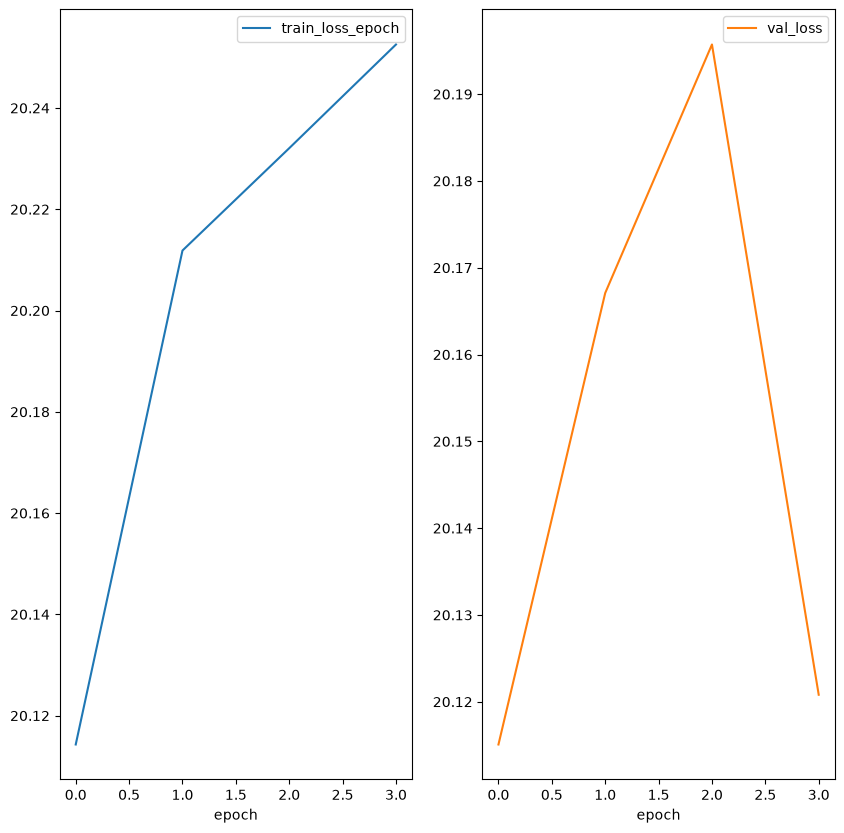

In [14]:
logs = pd.read_csv(cond_logged_dir+"/metrics.csv")
logs.groupby("epoch").agg(lambda x: x[~x.isna()].iloc[0] if (~x.isna()).sum()>0 else pd.NA).reset_index()[plot_cols+["epoch"]].dropna(axis=0, how="any").plot("epoch",plot_cols, sharey=False, subplots=True, layout=(-1,2), figsize=(10,10))

array([[<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>]], dtype=object)

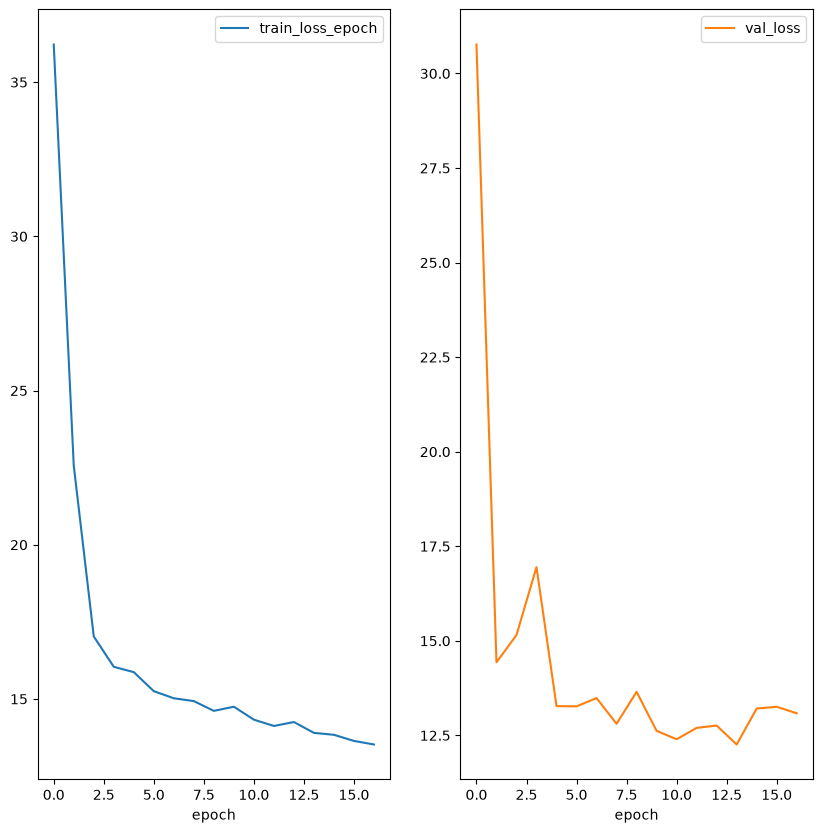

In [15]:
logs = pd.read_csv(pert_logged_dir+"/metrics.csv")
logs.groupby("epoch").agg(lambda x: x[~x.isna()].iloc[0] if (~x.isna()).sum()>0 else pd.NA).reset_index()[plot_cols+["epoch"]].dropna(axis=0, how="any").plot("epoch",plot_cols, sharey=False, subplots=True, layout=(-1,2), figsize=(10,10))

In [16]:
in_dim=data_module.n_vars
latent_dim = 512
dropout=0.1
encoder_kwargs = dict(
    hidden_dims=(in_dim, in_dim, in_dim, latent_dim, latent_dim),
    dropout=0
)
decoder_kwargs = dict(
    hidden_dims=(latent_dim+in_dim, in_dim, in_dim, in_dim, in_dim),
    dropout=dropout
)
cvae = cVAE(in_dim = in_dim, latent_dim=latent_dim, encoder_kwargs = encoder_kwargs, decoder_kwargs = decoder_kwargs, lr=0.00001, kl_midpoint=10)


{'hidden_dims': (2036, 2036, 2036, 512, 512), 'dropout': 0, 'in_dim': 2036, 'out_dim': 512, 'out_activation': None}
{'hidden_dims': (2036, 2036, 2036, 512, 512), 'dropout': 0, 'in_dim': 2036, 'out_dim': 512, 'out_activation': None}
{'hidden_dims': (2548, 2036, 2036, 2036, 2036), 'dropout': 0.1, 'out_dim': 2036, 'in_dim': 2548, 'out_activation': <class 'torch.nn.modules.activation.ReLU'>}


In [17]:
model, test_scores, logged_dir = train(
    cvae,
    data_module,
    max_epochs = 50,
    patience = 100,
    log_dir = log_dir,
    run_name = "cvae",
    seed = 0,
    test_on="last"
)
import gc
gc.collect()

Seed set to 0
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name          | Type    | Params | Mode  | FLOPs
----------------------------------------------------------
0 | module        | MLP     | 28.3 M | train | 0    
1 | loss          | MSELoss | 0      | train | 0    
2 | mu_encoder    | MLP     | 14.0 M | train | 0    
3 | sigma_encoder | MLP     | 14.0 M | train | 0   

Training for max 50 epochs...
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/n

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


...

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 867/867 [00:11<00:00, 78.34it/s, v_num=16, train_loss_step=11.30, train_loss_kl_step=0.754, train_loss_mse_x_step=10.60, val_pearson=0.821, val_loss=17.00, val_loss_kl=0.882, val_loss_mse_x=16.10, kl_factor=1.000, lr=1e-5, train_pearson=0.821, train_loss_epoch=16.60, train_loss_kl_epoch=0.872, train_loss_mse_x_epoch=15.80]


Restoring states from the checkpoint path at /omics/groups/OE0436/data/ntoulouse/scMLCourse/logs/cvae/version_16/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /omics/groups/OE0436/data/ntoulouse/scMLCourse/logs/cvae/version_16/last.ckpt
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/n564e/ntoulouse/.miniforge/envs/scml/lib/python3.14/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(annd

Testing DataLoader 0: 100%|██████████| 107/107 [00:00<00:00, 263.06it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       pearson_fc          0.030740339308977127
        pearson_x           0.8253132700920105
        test_loss           123.22195434570312
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


36

In [18]:
logs = pd.read_csv(logged_dir+"/metrics.csv")
logs

,epoch,kl_factor,lr,lr-Adam,pearson_fc,pearson_x,step,test_loss,train_latent_max,train_latent_mean,...,train_mu_mean,train_mu_min,train_pearson,train_x_hat_max,train_x_hat_mean,train_x_hat_min,val_loss,val_loss_kl,val_loss_mse_x,val_pearson
0,NaN,NaN,NaN,0.00001,NaN,NaN,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,NaN,NaN,NaN,NaN,NaN,19,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,NaN,NaN,NaN,NaN,NaN,29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4481,49.0,NaN,NaN,NaN,NaN,NaN,43339,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4482,49.0,NaN,NaN,NaN,NaN,NaN,43349,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4483,49.0,NaN,NaN,NaN,NaN,NaN,43349,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,16.97579,0.882065,16.093727,0.821146
4484,49.0,1.0,0.00001,NaN,NaN,NaN,43349,NaN,4.270903,0.00162,...,0.001615,-0.385458,0.820607,166.924973,0.722856,0.0,NaN,NaN,NaN,NaN


array([[<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>]], dtype=object)

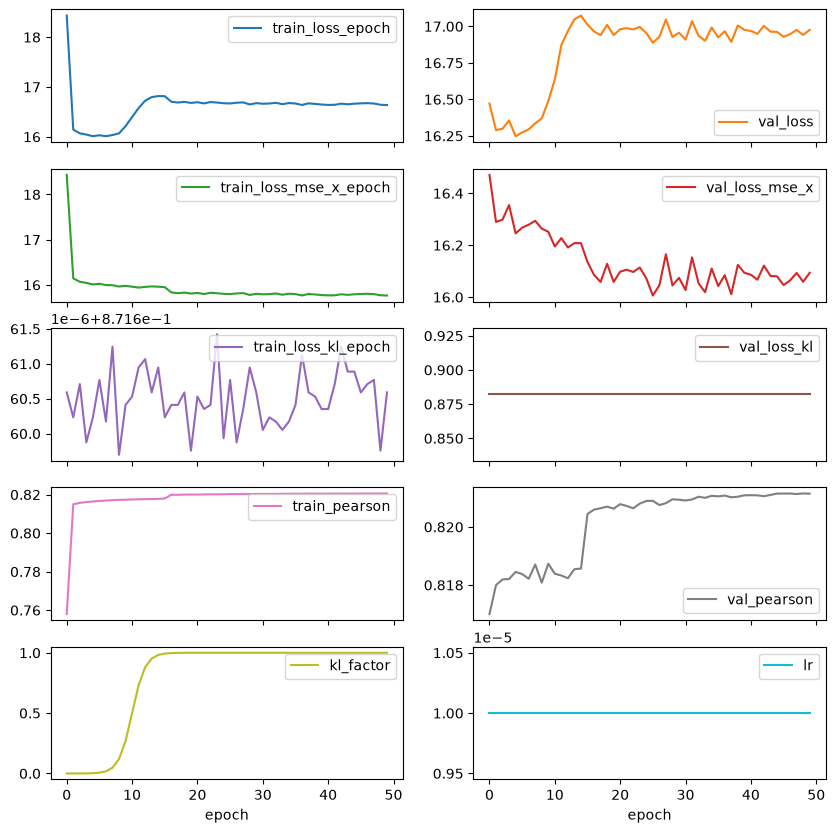

In [19]:
plot_cols = ["train_loss_epoch", "val_loss", "train_loss_mse_x_epoch", "val_loss_mse_x", "train_loss_kl_epoch", "val_loss_kl", "train_pearson", "val_pearson", "kl_factor", "lr"]
logs.groupby("epoch").agg(lambda x: x[~x.isna()].iloc[0] if (~x.isna()).sum()>0 else pd.NA).reset_index()[plot_cols+["epoch"]].dropna(axis=0, how="any").plot("epoch",plot_cols, sharey=False, subplots=True, layout=(-1,2), figsize=(10,10))

array([[<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>,
        <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>,
        <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>,
        <Axes: xlabel='epoch'>],
       [<Axes: xlabel='epoch'>, <Axes: xlabel='epoch'>,
        <Axes: xlabel='epoch'>]], dtype=object)

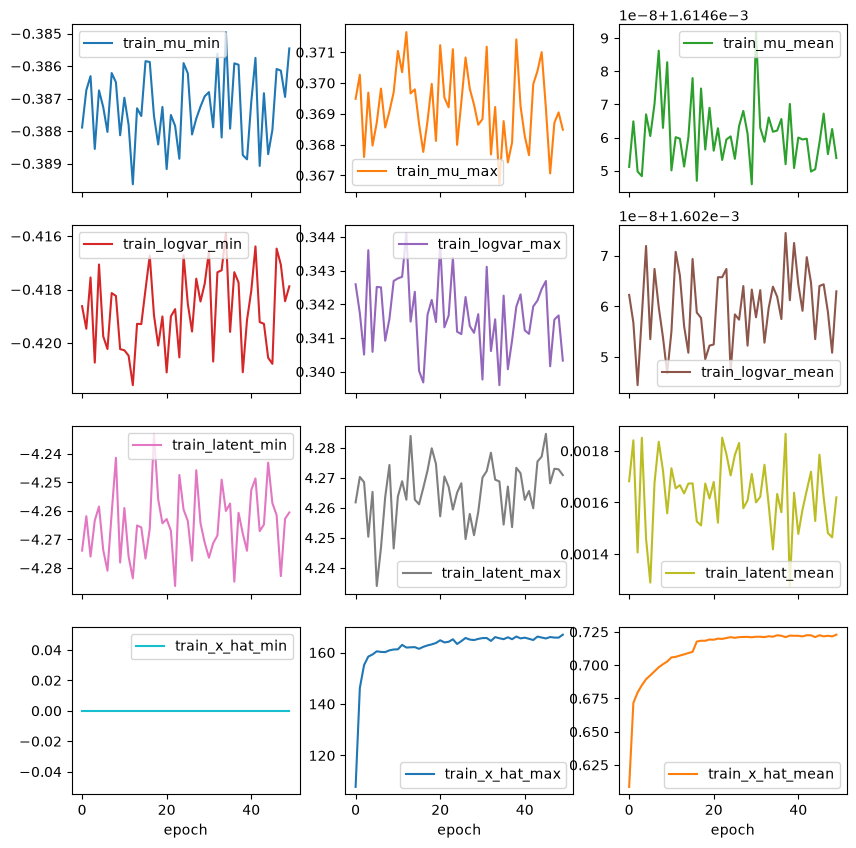

In [20]:
plot_cols = ["train_mu_min",
"train_mu_max",
"train_mu_mean",
"train_logvar_min",
"train_logvar_max",
"train_logvar_mean",
"train_latent_min",
"train_latent_max",
"train_latent_mean",
"train_x_hat_min",
"train_x_hat_max",
"train_x_hat_mean",]
logs.groupby("epoch").agg(lambda x: x[~x.isna()].iloc[0] if (~x.isna()).sum()>0 else pd.NA).reset_index()[plot_cols+["epoch"]].dropna(axis=0, how="any").plot("epoch",plot_cols, sharey=False, subplots=True, layout=(4,3), figsize=(10,10))